In [7]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import sigpy.mri as mr
import numpy as np
import os
import jax as jx
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

print(project_root)

import aymansigmri as asm
vmax = np.float64(0.006781407399631379)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE


In [2]:
def softimpute_ALS_ortho_del(X_H, M_H, rank, lamda, n_iters, seed, verbose=False, verbose2=False):
        print("starting ALS")
        D = np.eye(rank, dtype=np.complex64)
        m,n = np.shape(X_H)
        rng = np.random.default_rng(seed)
        U = rng.standard_normal((m, rank)) + 1j * rng.standard_normal((m, rank))
        V = np.zeros((n, rank),dtype=np.complex64)
        U, _ = np.linalg.qr(U)


        A = np.dot(U,D)
        B = np.dot(V,D)
        iter_count = 0
        ABt = A @ B.conj().T
        norms = {'A': [], 'B': [], 'ABt': [], 'X_star': [], 'rel_change': [], 'residual': []}
        if verbose:
             print("starting ALS iters")
        while iter_count < n_iters:
            ABt_prev = ABt
            X_star = np.where(M_H, X_H, ABt)
            B = X_star.conj().T @ A @ np.linalg.inv(A.conj().T @ A + lamda*D)
            ABt = A @ B.conj().T
    
            X_star = np.where(M_H, X_H, ABt)
            A = X_star @ B @ np.linalg.inv(B.conj().T @ B + lamda*D)
            ABt = A @ B.conj().T

            norms['A'].append(np.linalg.norm(A))
            norms['B'].append(np.linalg.norm(B))
            norms['ABt'].append(np.linalg.norm(ABt))
            norms['X_star'].append(np.linalg.norm(X_star))
            gap = ~M_H
            norms['rel_change'].append(
                np.linalg.norm((ABt - ABt_prev)[gap]) / np.linalg.norm(ABt_prev[gap]))
            norms['residual'].append(np.linalg.norm((ABt - X_star)[gap]))

            ABt = A @ B.conj().T
            iter_count += 1
            if verbose2:
                print(f'iter {iter_count} done')
        return(ABt, norms)


def LORAKS_imputeals_ortho_del(n_iters, window_size, cartesian_inputkspace, dtg_mask, rank, lamda, stride, im_dim, enlarged_kspace, seed, inner_start, inner_end):
    ksp_forhankel = cartesian_inputkspace.copy()
    ksp_zerod = ksp_forhankel * dtg_mask
    hankel_matrix, n_coils, Numx, Numy = asm.hankel_2(kspace=ksp_zerod, w=window_size, s=stride)
    mask_coiled = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
    masked_hankel, *_ = asm.hankel_2(kspace=mask_coiled, w=window_size, s=stride)
    masked_hankel = np.real(masked_hankel) > 0.5

    filled_hankel, norms = softimpute_ALS_ortho_del(
        X_H=hankel_matrix, M_H=masked_hankel, rank=rank,
        lamda=lamda, n_iters=n_iters, seed=seed)

    kspace_cart_coils_recon = asm.hankel_H_averaged_2(filled_hankel, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size, s=stride)
    kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
    output_kspace = kspace_cart_coils_recon.copy()
    filled_ksp, _ = asm.rebuild(output_kspace=output_kspace, inner_start=inner_start, inner_end=inner_end, enlarged_kspace=enlarged_kspace, im_dim=im_dim)
    im_grid0 = sp.ifft(filled_ksp, axes=(-2, -1))
    im_0 = np.sum(np.abs(im_grid0)**2, axis=0)**0.5

    return (im_0, norms)

In [ ]:
rank = 40                                    # fixed rank
window = 11
num_iters = 250

gap_vals = [1, 2, 3, 4]
lamda_vals = [1e-5, 1e-4, 1e-3, 1e-2]

zte_radial_kspace_gt, zte_radial_coords_gt = asm.generate_zte_data_OLD(
    ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

dcf_gt = (zte_radial_coords_gt[..., 0] ** 2 + zte_radial_coords_gt[..., 1] ** 2) ** 0.5
im_grid_gt = sp.nufft_adjoint(zte_radial_kspace_gt * dcf_gt, zte_radial_coords_gt)
ground_truth = np.sum(np.abs(im_grid_gt) ** 2, axis=0) ** 0.5


def build_gap_data(n_gap, resize_wid, inner_wid):
    ksp_dlt, crd_dlt, ksp_zero, crd_zero, mask = asm.generate_zte_data(
        ksp=ksp, coord=coord, n_missing=n_gap, undersampling_factor=1)

    cart_zte = asm.nufft_gridding(kspace=ksp_zero, coords=crd_zero)
    cart_enl = asm.zero_padding(cart_kspace=cart_zte, resize_x=resize_wid, resize_y=resize_wid)
    inner_region, start, end = asm.inner_portion(enlarged_kspace=cart_enl, inner_sidelen=inner_wid)
    dtg_mask = asm.circular_gap_mask(inner_wid, n_gap)
    return inner_region, cart_enl, start, end, dtg_mask


recons_gap = {}
deltas_gap = {}
errors_gap = np.zeros((len(gap_vals), len(lamda_vals)))

for gi, n_gap in enumerate(gap_vals):
    window_size = window
    inner_region, cart_enl, start, end, dtg_mask = build_gap_data(n_gap, 512, 50)

    for li, lamda in enumerate(lamda_vals):
        recon, deltas = LORAKS_imputeals_ortho_del(
            n_iters=num_iters, window_size=window_size,
            cartesian_inputkspace=inner_region, dtg_mask=dtg_mask,
            rank=rank, lamda=lamda, stride=1, im_dim=256,
            enlarged_kspace=cart_enl, seed=42,
            inner_start=start, inner_end=end,
        )
        recons_gap[(n_gap, lamda)] = recon
        deltas_gap[(n_gap, lamda)] = deltas
        errors_gap[gi, li] = np.sqrt(np.sum(np.abs(recon - ground_truth) ** 2))
        print(f"n={n_gap}, w={window_size}, rank={rank}, lambda={lamda:.0e}: "
              f"l2 error = {errors_gap[gi, li]:.4f}, "
              f"final delta = {deltas['rel_change'][-1]:.2e}")

r = 1: 9 points masked out
starting ALS


/var/folders/lp/mmccs9596xb7321q5q75xnj00000gn/T/ipykernel_42847/1195955351.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  np.linalg.norm((ABt - ABt_prev)[gap]) / np.linalg.norm(ABt_prev[gap]))


n=1, w=11, rank=40, lambda=1e-05: l2 error = 0.0494, final delta = 2.99e-06
starting ALS
n=1, w=11, rank=40, lambda=1e-04: l2 error = 0.0501, final delta = 1.19e-05
starting ALS
n=1, w=11, rank=40, lambda=1e-03: l2 error = 0.0514, final delta = 3.62e-05
starting ALS
n=1, w=11, rank=40, lambda=1e-02: l2 error = 0.0577, final delta = 7.17e-06
r = 2: 21 points masked out
starting ALS
n=2, w=11, rank=40, lambda=1e-05: l2 error = 0.0785, final delta = 1.90e-04
starting ALS
n=2, w=11, rank=40, lambda=1e-04: l2 error = 0.0846, final delta = 1.76e-04
starting ALS
n=2, w=11, rank=40, lambda=1e-03: l2 error = 0.0945, final delta = 2.12e-04
starting ALS
n=2, w=11, rank=40, lambda=1e-02: l2 error = 0.1409, final delta = 1.30e-04
r = 3: 37 points masked out
starting ALS
n=3, w=11, rank=40, lambda=1e-05: l2 error = 0.2882, final delta = 4.87e-04
starting ALS
n=3, w=11, rank=40, lambda=1e-04: l2 error = 0.3051, final delta = 4.84e-04
starting ALS
n=3, w=11, rank=40, lambda=1e-03: l2 error = 0.3214, f

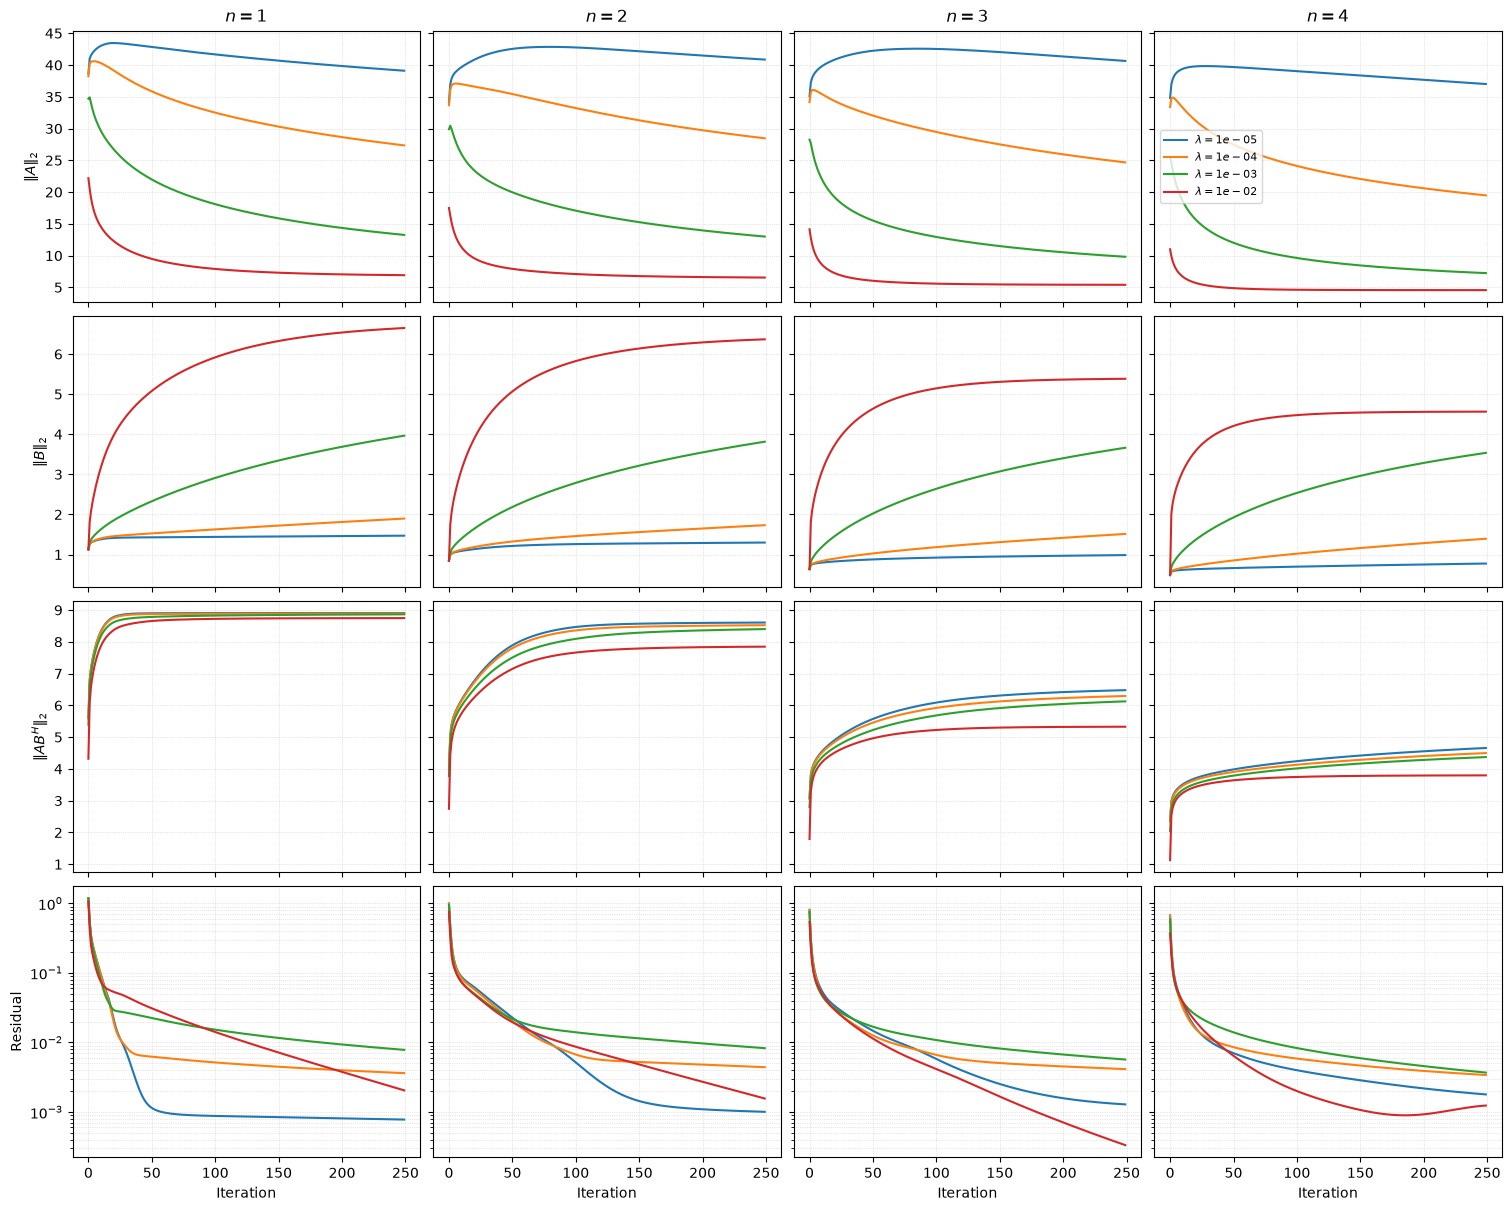

In [5]:
skip = 0

quantities = ['A', 'B', 'ABt', 'residual']
row_labels = [r"$\|A\|_2$", r"$\|B\|_2$", r"$\|AB^H\|_2$", r"Residual"]

fig, axes = plt.subplots(4, len(gap_vals), figsize=(15, 12),
                         constrained_layout=True, sharex=True, sharey='row')

for col, n in enumerate(gap_vals):
    for li, lamda in enumerate(lamda_vals):
        norms = deltas_gap[(n, lamda)]
        for row, key in enumerate(quantities):
            ax = axes[row, col]
            series = norms[key]
            iters = range(skip, len(series))
            ax.plot(iters, series[skip:], color=f'C{li}', lw=1.5,
                    label=rf"$\lambda={lamda:.0e}$")
            ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.6)
    axes[0, col].set_title(f"$n={n}$")

for ax in axes[3, :]:
    ax.set_yscale('log')

for ax in axes[-1, :]:
    ax.set_xlabel("Iteration")

for row, lbl in enumerate(row_labels):
    axes[row, 0].set_ylabel(lbl)

axes[0, -1].legend(fontsize=8)

fig.savefig('imputeals_norms.pdf', bbox_inches='tight')
plt.show()

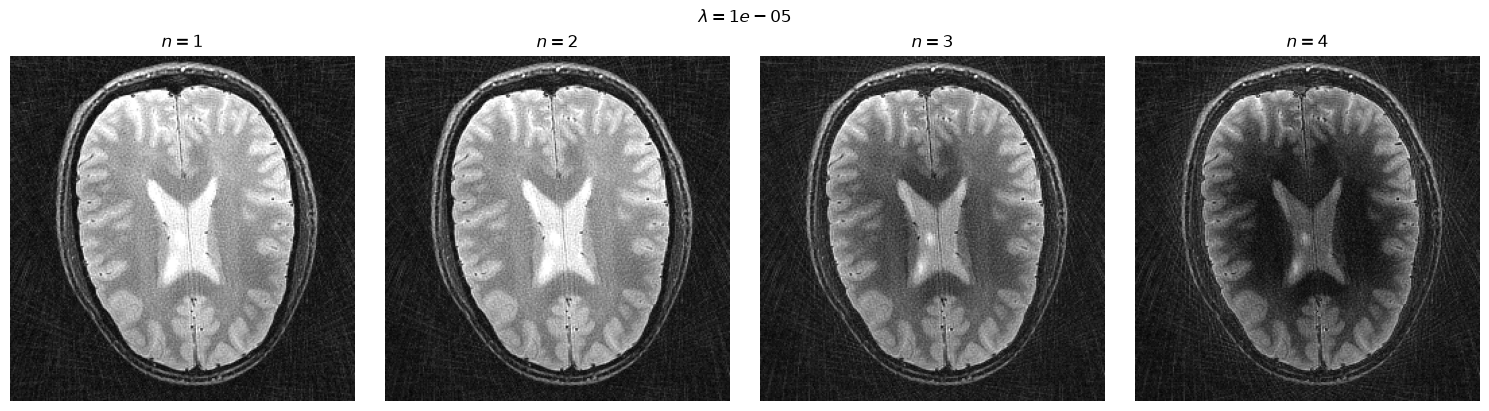

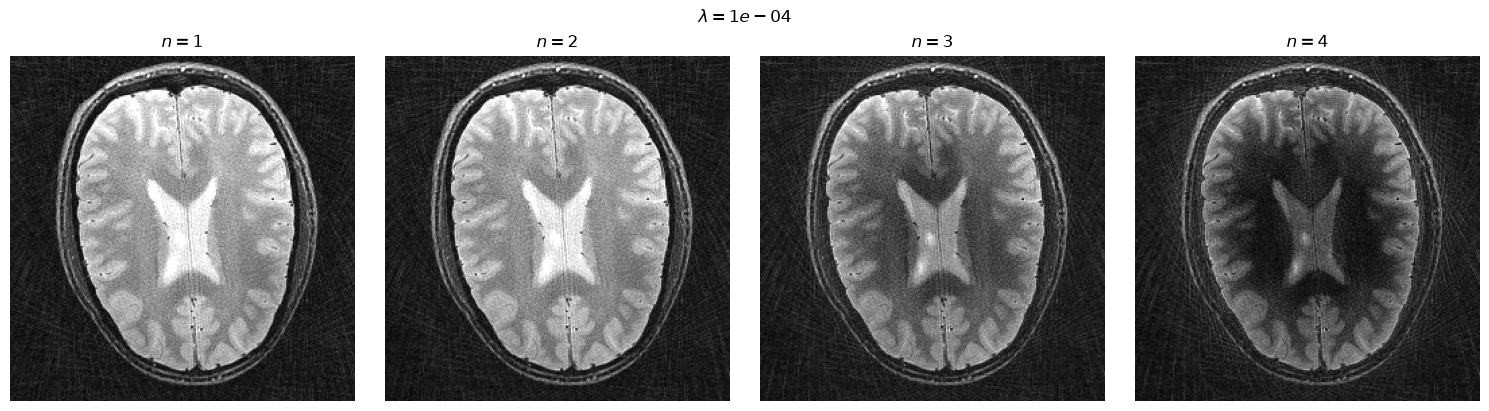

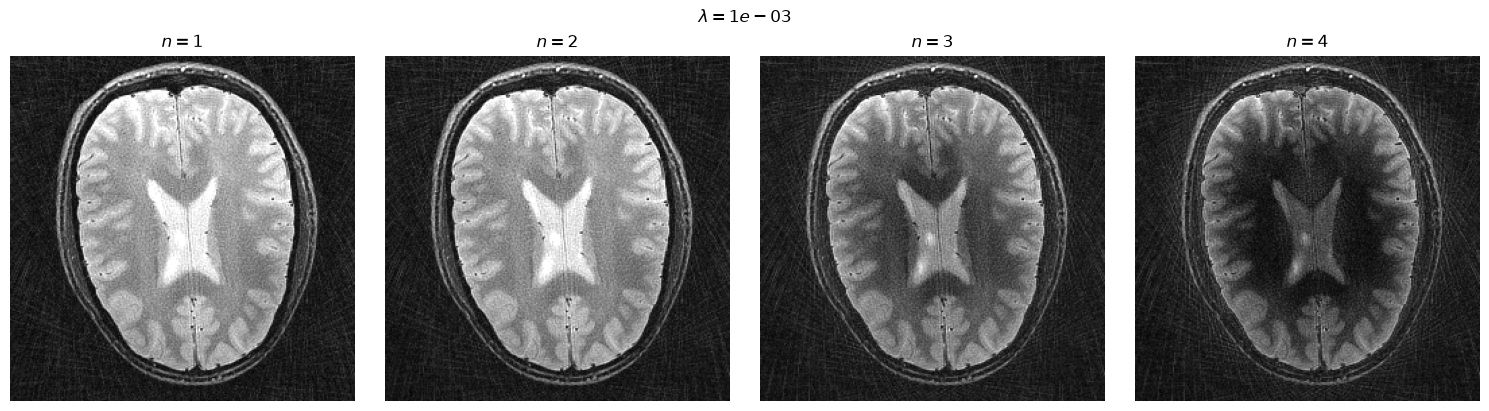

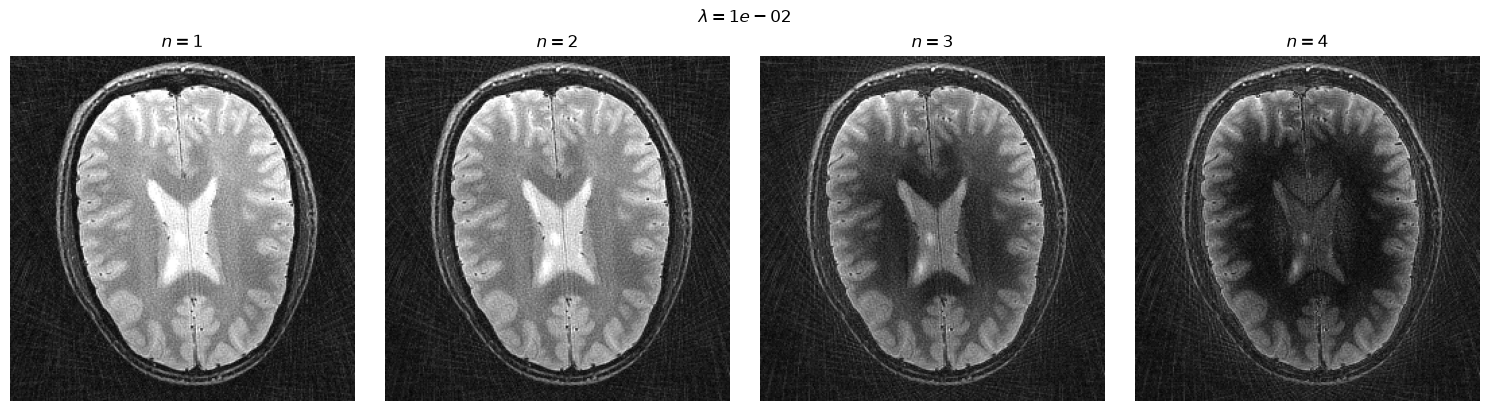

In [8]:
for lamda in lamda_vals:
    fig, axes = plt.subplots(1, len(gap_vals), figsize=(15, 4),
                             constrained_layout=True)
    for col, n in enumerate(gap_vals):
        ax = axes[col]
        ax.imshow(np.abs(recons_gap[(n, lamda)]), cmap='gray', vmax=vmax)
        ax.set_title(f"$n={n}$")
        ax.axis('off')
    fig.suptitle(rf"$\lambda={lamda:.0e}$")
    #fig.savefig(f'recon_lambda_{lamda:.0e}.pdf', bbox_inches='tight')
    plt.show()